# ML Student Performance Prediction & Model Evaluation



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

pd.set_option('display.max_columns', None)


In [3]:

df = pd.read_csv('Day18_19_student_habits_performance.csv')

print("Shape:", df.shape)
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## Initial Inspection

In [4]:
print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (1000, 16)

Column names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data types:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score          

### Initial observation
The dataset contains **1,000 students and 16 columns**. Most variables are numerical, while variables such as gender, part-time job, diet quality, parental education level, internet quality and extracurricular participation are categorical.

There are **91 missing values in `parental_education_level`**. The remaining columns do not have missing values.

## Basic Statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


## Numerical and Categorical Variables

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical variables:")
print(numeric_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


##  Distribution of Exam Scores

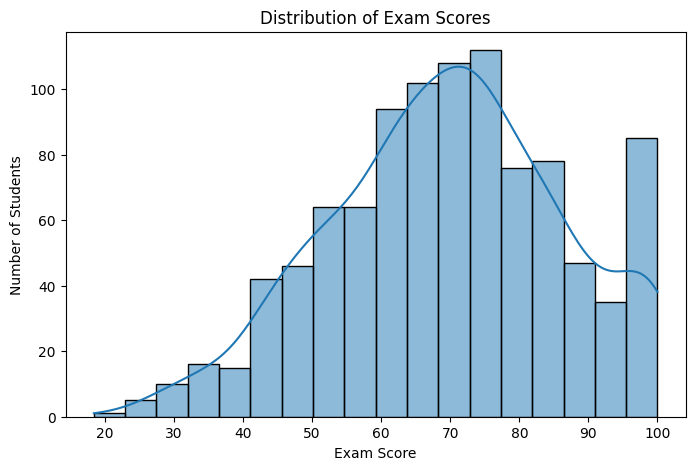

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(df['exam_score'], kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.show()

The exam scores cover a fairly wide range. The distribution is useful for checking whether a simple regression model is reasonable before moving to prediction.

## Categorical Variable Distributions

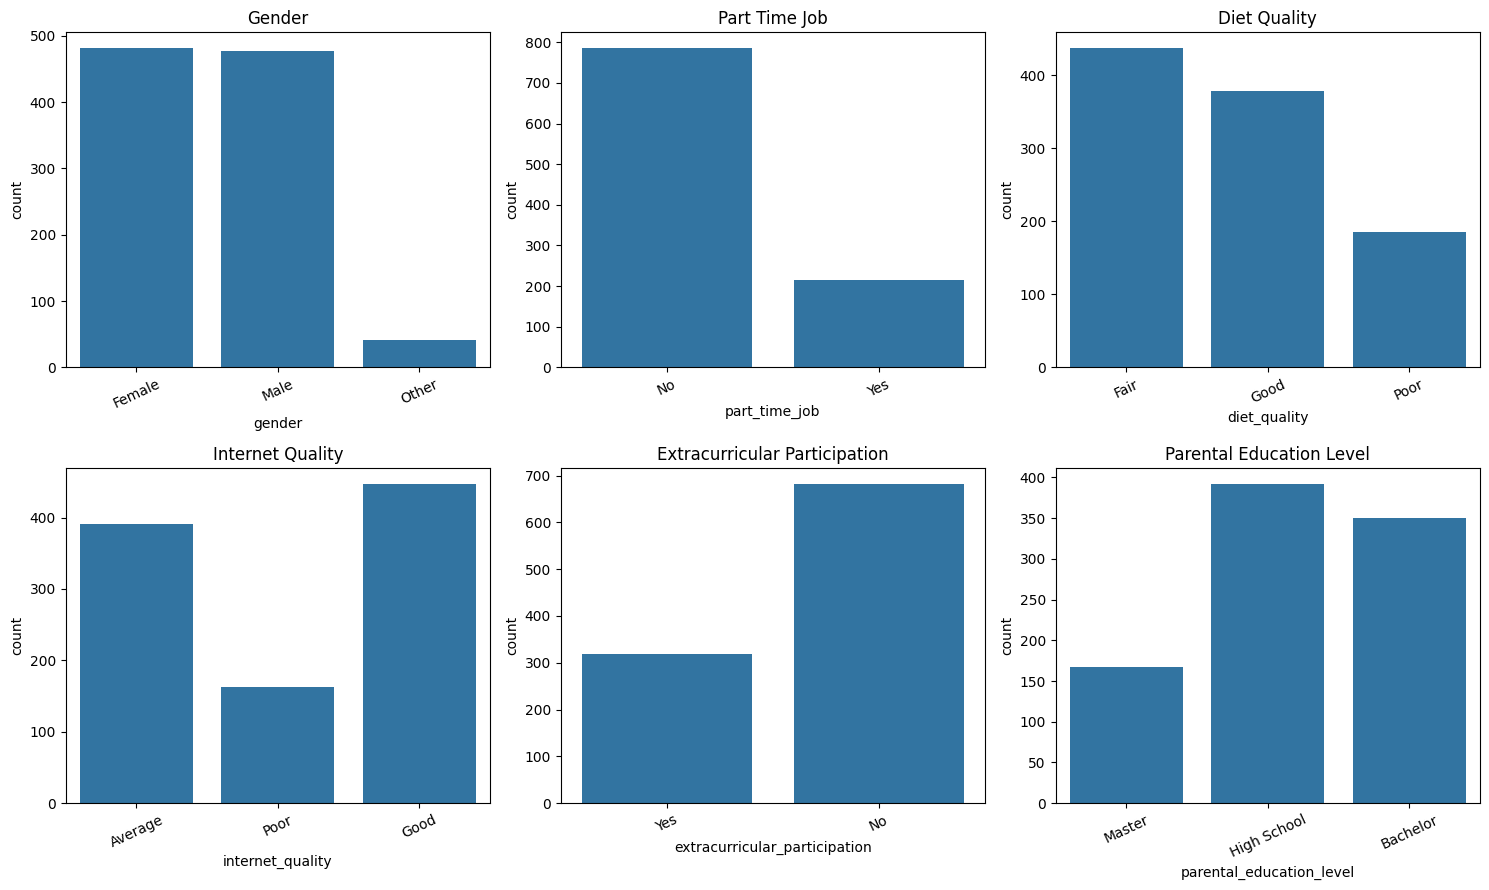

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
cols = [
    'gender', 'part_time_job', 'diet_quality',
    'internet_quality', 'extracurricular_participation',
    'parental_education_level'
]

for ax, col in zip(axes.flat, cols):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(col.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()

## Relationships with Exam Score

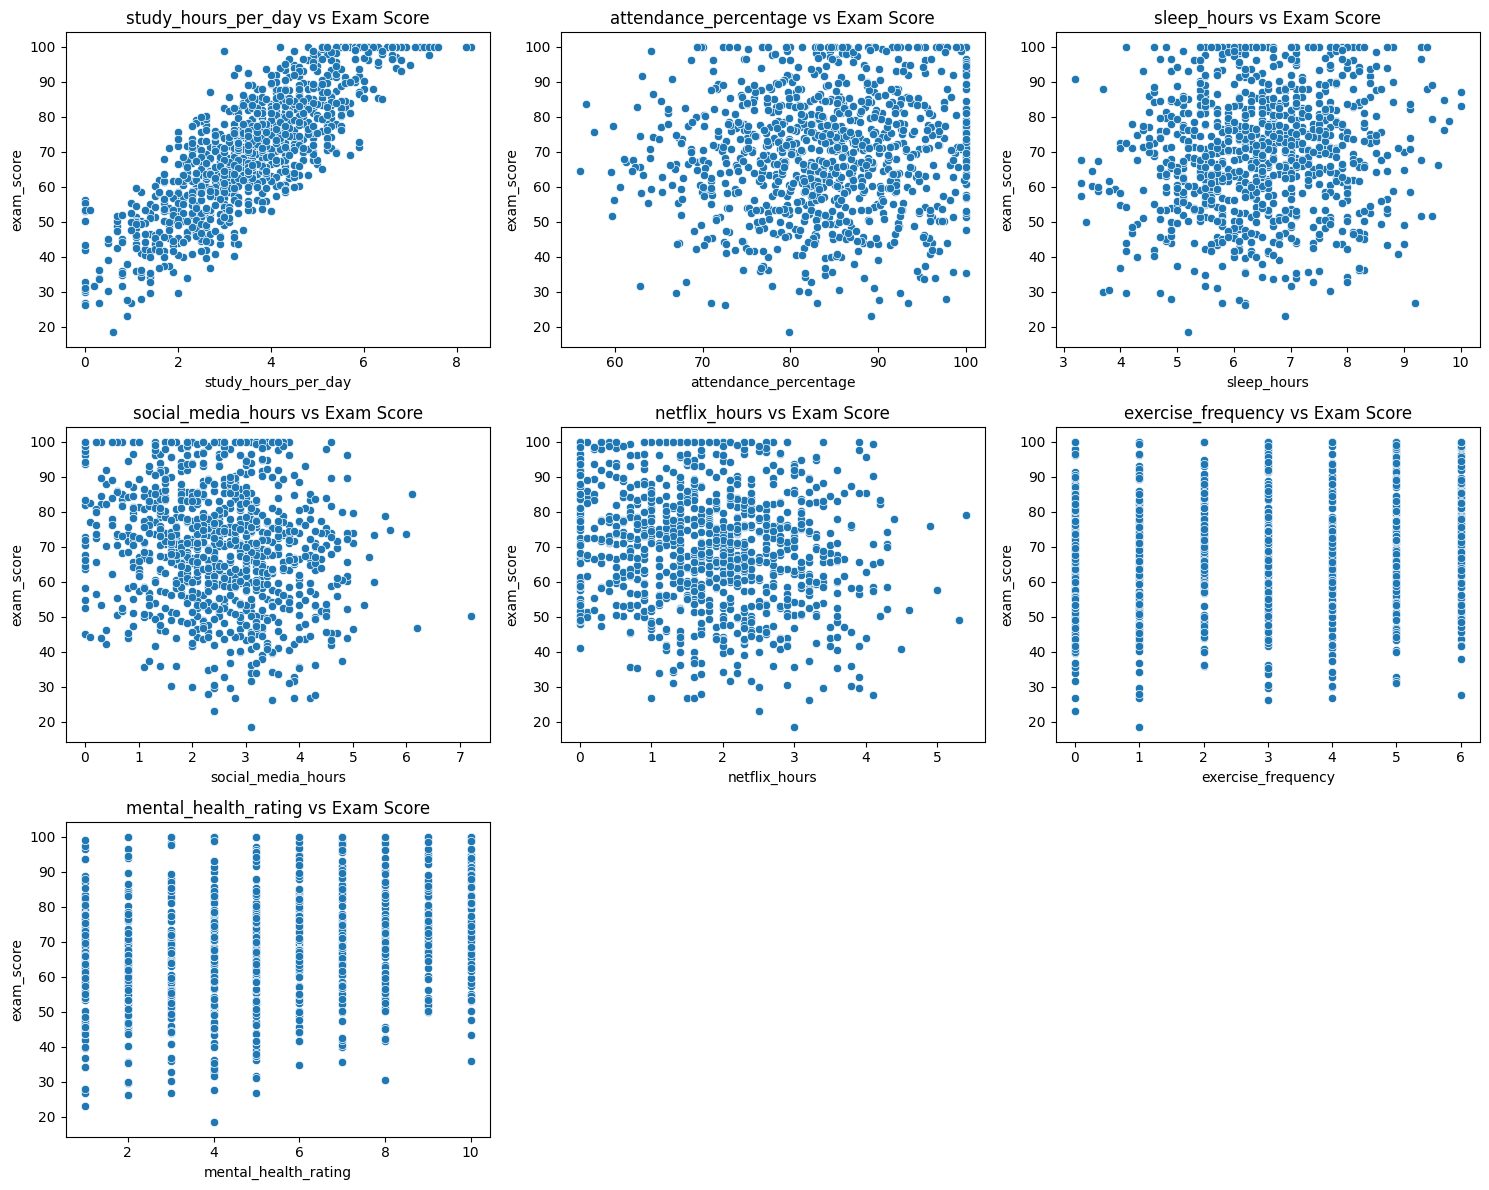

In [9]:
selected = [
    'study_hours_per_day', 'attendance_percentage', 'sleep_hours',
    'social_media_hours', 'netflix_hours', 'exercise_frequency',
    'mental_health_rating'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flat, selected):
    sns.scatterplot(data=df, x=col, y='exam_score', ax=ax)
    ax.set_title(f'{col} vs Exam Score')

for ax in axes.flat[len(selected):]:
    ax.remove()

plt.tight_layout()
plt.show()

## Correlation with Exam Score

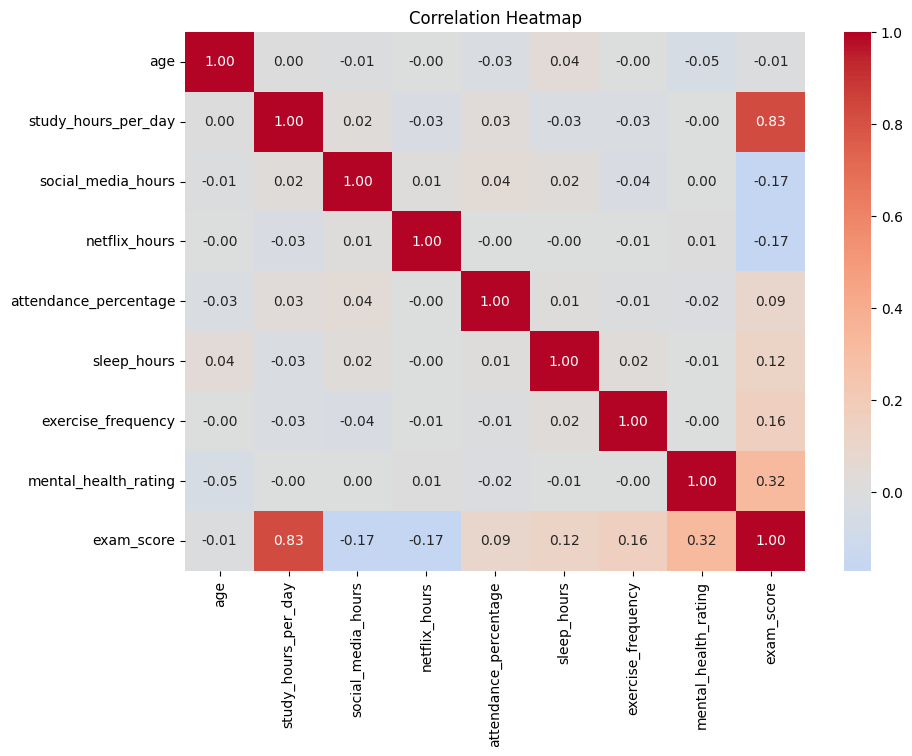

Correlation with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


In [10]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print("Correlation with exam_score:")
print(corr['exam_score'].sort_values(ascending=False))

### EDA finding
The strongest relationship with `exam_score` is **study hours per day**, with a correlation of about **0.83**. Mental health rating has a moderate positive relationship (about **0.32**), while exercise frequency and sleep hours have smaller positive relationships.

Social media hours and Netflix hours show small negative relationships with exam score. Attendance has a positive relationship, but it is much weaker than study hours in this dataset.

Correlation shows association, not causation.

## Check Potential Outliers

In [11]:
outlier_report = []

for col in numeric_cols:
    if col == 'student_id':
        continue
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append([col, q1, q3, iqr, lower, upper, count])

outlier_df = pd.DataFrame(
    outlier_report,
    columns=['Variable', 'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Outliers']
)

outlier_df

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Outliers
0,age,18.750,23.000,4.250,12.3750,29.3750,0
1,study_hours_per_day,2.600,4.500,1.900,-0.2500,7.3500,7
2,social_media_hours,1.700,3.300,1.600,-0.7000,5.7000,5
3,netflix_hours,1.000,2.525,1.525,-1.2875,4.8125,4
4,attendance_percentage,78.000,91.025,13.025,58.4625,110.5625,3
5,sleep_hours,5.600,7.300,1.700,3.0500,9.8500,2
6,exercise_frequency,1.000,5.000,4.000,-5.0000,11.0000,0
7,mental_health_rating,3.000,8.000,5.000,-4.5000,15.5000,0
8,exam_score,58.475,81.325,22.850,24.2000,115.6000,2


Only a small number of observations are flagged as outliers in most numerical variables. I will not automatically remove them because unusually high study time, screen time or exam scores can still represent genuine students. The model can therefore be trained on the original observations.

## Data Preparation

In [12]:
# student_id is an identifier, so it is not useful as a predictive feature.
model_features = [
    'age',
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exercise_frequency',
    'mental_health_rating'
]

X = df[model_features]
y = df['exam_score']

print("Features used for the model:")
print(model_features)

print("\nMissing values in selected features:")
print(X.isnull().sum())


Features used for the model:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Missing values in selected features:
age                      0
study_hours_per_day      0
social_media_hours       0
netflix_hours            0
attendance_percentage    0
sleep_hours              0
exercise_frequency       0
mental_health_rating     0
dtype: int64


### Why these features?
- `student_id` is removed because it is only an identifier.
- The model uses numerical features that are relevant to student habits and performance.
- These selected features have no missing values in this dataset, so no extra imputation is required.
- Categorical variables were explored during EDA but are not included in the first model so that the model stays simple and easy to interpret.


## Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


##  Linear Regression Model

In [14]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

train_pred = linear_model.predict(X_train)
test_pred = linear_model.predict(X_test)


### Linear Regression formula

**Predicted exam score = intercept + (coefficient × feature values)**

The model learns the relationship between the prepared student features and `exam_score`.

##  Regression Evaluation

In [15]:
train_mae = mean_absolute_error(y_train, train_pred)
test_mae = mean_absolute_error(y_test, test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

train_r2 = r2_score(y_train, train_pred)
test_r2 = r2_score(y_test, test_pred)

regression_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Training': [train_mae, train_rmse, train_r2],
    'Testing': [test_mae, test_rmse, test_r2]
})

regression_results

,Metric,Training,Testing
0,MAE,4.235716,4.130186
1,RMSE,5.375375,5.091268
2,R² Score,0.900981,0.898915


### Regression result
The testing **MAE is about 4.13 marks**, meaning the predicted exam score is off by roughly 4 marks on average.

The testing **RMSE is about 5.09**, while the testing **R² is about 0.90**. This means the model explains a large part of the variation in exam scores.

The training and testing results are also very close, so there is no strong sign of overfitting.


## Actual vs Predicted Scores

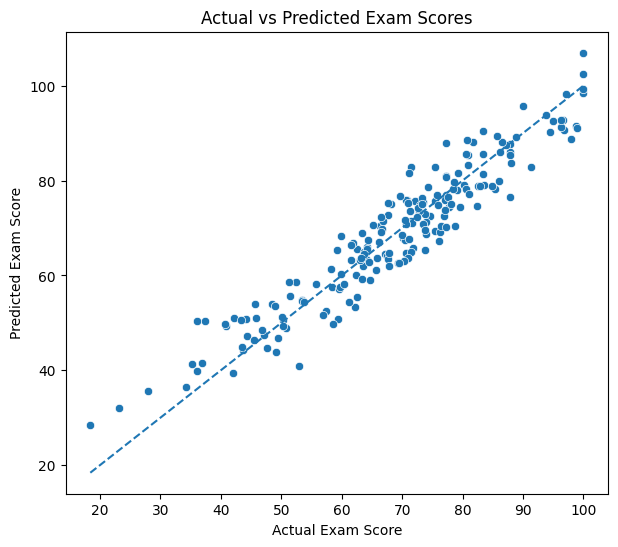

In [16]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Scores')
plt.show()

## Create Pass/Fail Target

In [17]:
# 50 marks is the passing threshold
df['pass_fail'] = np.where(df['exam_score'] >= 50, 'Pass', 'Fail')

print(df['pass_fail'].value_counts())
print("\nPass percentage:", round((df['pass_fail'] == 'Pass').mean() * 100, 2), "%")

pass_fail
Pass    869
Fail    131
Name: count, dtype: int64

Pass percentage: 86.9 %


## Prepare Data for Classification

In [18]:
X_class = df[model_features]
y_class = df['pass_fail']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)


## Logistic Regression Classification Model

In [19]:
classification_model = LogisticRegression(max_iter=1000)

classification_model.fit(X_train_c, y_train_c)

train_class_pred = classification_model.predict(X_train_c)
test_class_pred = classification_model.predict(X_test_c)


##  Classification Evaluation

In [20]:
def classification_metrics(y_true, pred):
    return [
        accuracy_score(y_true, pred),
        precision_score(y_true, pred, pos_label='Pass'),
        recall_score(y_true, pred, pos_label='Pass'),
        f1_score(y_true, pred, pos_label='Pass')
    ]

classification_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Training': classification_metrics(y_train_c, train_class_pred),
    'Testing': classification_metrics(y_test_c, test_class_pred)
})

classification_results

,Metric,Training,Testing
0,Accuracy,0.956250,0.965000
1,Precision,0.970085,0.977143
2,Recall,0.979856,0.982759
3,F1-score,0.974946,0.979943


### Classification result
The testing accuracy is about **96.5%**. Precision, recall and F1-score are also high.

Because the pass class is larger than the fail class, accuracy should not be considered alone. Precision, recall and F1-score give a better picture of how well the model identifies students who pass.


## Confusion Matrix

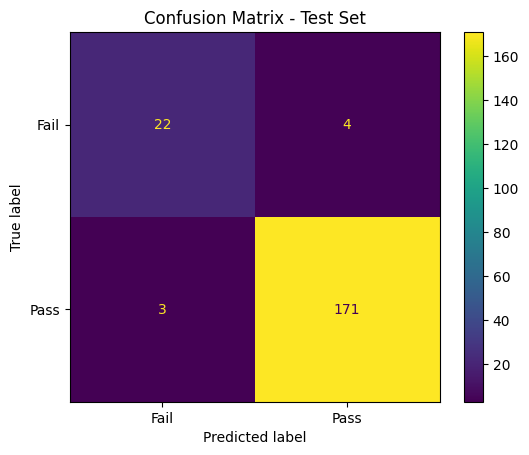

Confusion matrix:
[[ 22   4]
 [  3 171]]


In [21]:
cm = confusion_matrix(y_test_c, test_class_pred, labels=['Fail', 'Pass'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Fail', 'Pass']
)

disp.plot()
plt.title('Confusion Matrix - Test Set')
plt.show()

print("Confusion matrix:")
print(cm)

### Confusion matrix interpretation
The confusion matrix shows the number of correct Pass/Fail predictions and the cases where the model classified a student incorrectly.

The model performs well overall, with only a small number of students being misclassified in the test set.

## Training vs Testing Performance

In [22]:
print("Regression")
print("Training R²:", round(train_r2, 4))
print("Testing R² :", round(test_r2, 4))

print("\nClassification")
print("Training Accuracy:", round(accuracy_score(y_train_c, train_class_pred), 4))
print("Testing Accuracy :", round(accuracy_score(y_test_c, test_class_pred), 4))

Regression
Training R²: 0.901
Testing R² : 0.8989

Classification
Training Accuracy: 0.9563
Testing Accuracy : 0.965


### Overfitting / Underfitting check

For regression, the training R² is about **0.901** and testing R² is about **0.899**. The small difference suggests that the model generalizes well and is not strongly overfitting.

For classification, training accuracy is about **95.63%** and testing accuracy is about **96.50%**. The results are very close.

So, based on these results, there is **no major sign of overfitting or underfitting**.


## Important Findings from the EDA and Models

In [23]:
# Numeric correlations with exam score
df.select_dtypes(include=np.number).corr()['exam_score'].sort_values(ascending=False)

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


### Main findings
1. **Study hours are the strongest factor related to exam score.** The correlation is around 0.83, much stronger than the other numerical variables.
2. **Mental health rating has a moderate positive relationship** with exam performance.
3. **Social media and Netflix hours have negative relationships** with exam score, although these relationships are much weaker than study hours.
4. **The regression model performs strongly**, with a testing R² of about 0.90 and average prediction error of about 4.13 marks.
5. **The classification model also performs strongly**, with around 96.5% testing accuracy and similarly high precision, recall and F1-score.


## Five Meaningful Statistical Insights

### 1. Study time matters the most
Students who spend more time studying tend to have higher exam scores. Among the numerical variables, study hours have the strongest relationship with performance.

### 2. Mental wellbeing is also connected with performance
Mental health rating has a moderate positive relationship with exam score. This suggests that student wellbeing may be relevant when looking at academic performance.

### 3. Entertainment and social media time show a negative pattern
Higher social media and Netflix hours are associated with lower exam scores in this dataset. However, the relationships are not as strong as the study-hours relationship.

### 4. The regression model gives useful predictions
The model explains around 90% of the variation in exam scores, with a testing MAE of about 4.13 marks. This indicates that the selected student habits and characteristics contain useful information for predicting performance.

### 5. Pass/Fail prediction is highly accurate
The Logistic Regression model achieved about 96.5% testing accuracy, with high precision, recall and F1-score. The close training and testing results suggest that it generalizes well on this dataset.


##  Conclusion

Overall, the analysis shows that **study habits are the clearest indicator of exam performance in this dataset**. Mental health also has a noticeable positive relationship, while higher social media and Netflix usage show weaker negative relationships.

The Linear Regression model was able to predict exam scores with a relatively small error, while the Logistic Regression model performed well in identifying Pass and Fail students. Since training and testing performance are very similar for both models, there is no strong evidence of overfitting.

These results should be treated as patterns in this particular dataset rather than proof that one habit directly causes better or worse academic performance.


##  Final Model Summary

In [24]:
summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Logistic Regression'],
    'Task': ['Exam score prediction', 'Pass/Fail classification'],
    'Test Performance': [
        f'R² = {test_r2:.3f}, MAE = {test_mae:.2f}',
        f'Accuracy = {accuracy_score(y_test_c, test_class_pred):.3f}, F1 = {f1_score(y_test_c, test_class_pred, pos_label="Pass"):.3f}'
    ]
})

summary

,Model,Task,Test Performance
0,Linear Regression,Exam score prediction,"R² = 0.899, MAE = 4.13"
1,Logistic Regression,Pass/Fail classification,"Accuracy = 0.965, F1 = 0.980"
